# **In Silico Toxicology Modelling**
### October 2024
Authors: Srijit Seal seal[at]broadinstitute.org

In this notebook, we will look at modelling PK parameters using a regression models from chemical structures, physicochemical properties, and cell morphology descriptors

For a background to programming and ML models see: https://colab.research.google.com/drive/15yksF81YtkwwwL853SuLIVW3h8yHYqtA?usp=sharing

Setup (run this block using the play button or Shift+Enter to install packages and download required data)

In [ ]:
%pip install rdkit seaborn shap
!wget https://raw.githubusercontent.com/srijitseal/BTS_insilicotox_Workshop/refs/heads/main/data/Lombardo_Human_PK_parameters.csv
!wget https://raw.githubusercontent.com/srijitseal/BTS_insilicotox_Workshop/refs/heads/main/data/Cell_Painting_PK_Overlap.csv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.1/33.1 MB 14.3 MB/s eta 0:00:00
--2024-10-27 21:11:08--  https://raw.githubusercontent.com/srijitseal/BTS_insilicotox_Workshop/refs/heads/main/data/Lombardo_Human_PK_parameters.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 174374 (170K) [text/plain]
Saving to: ‘Lombardo_Human_PK_parameters.csv’

Lombardo_Human_PK_p 100%[===================>] 170.29K  --.-KB/s    in 0.03s   

2024-10-27 21:11:08 (6.05 MB/s) - ‘Lombardo_Human_PK_parameters.csv’ saved [174374/174374]

--2024-10-27 21:11:08--  https://raw.githubusercontent.com/srijitseal/BTS_insilicotox_Workshop/refs/heads/main/data/Cell_Painting_PK_Overlap.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133,

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np

## Exercise 1: Regression modelling VDss with RDKit Descriptors

In this exercise we will use Random Forests to model VDss with RDKit Descriptors.

### Data Cleaning

The first step is to load and clean the dataset.

First, we will read in the data file Lombardo_Human_PK_parameters.csv. This contains human PK parameters, extracted from Lombardo et al (https://pubmed.ncbi.nlm.nih.gov/30115648/)

In [ ]:
pk_data = pd.read_csv("Lombardo_Human_PK_parameters.csv")
pk_data.head()

,smiles_r,human_VDss_L_kg,human_CL_mL_min_kg,human_fup,human_mrt,human_thalf,MW,HBA,HBD,TPSA_NO,RotBondCount,MoKa.LogP,MoKa.LogD7.4,molecular_weight_smiles_r
0,C#CCC(Cc1cnc2nc(N)nc(N)c2n1)c1ccc(C(=O)NC(CCC(...,1.015,4.35,0.33,3.70,15.0,477.47,12.0,5.0,207.3,11.0,0.35,-6.0,475.161514
1,C#CCCCC(=O)c1cc(C(C)(C)C)c([O-])c(C(C)(C)C)c1,12.000,8.90,NaN,22.30,50.7,300.44,2.0,1.0,37.3,6.0,5.40,5.4,299.201654
2,C#CCN(Cc1cc2c(=O)nc(C)[n-]c2cc1C)c1ccc(C(=O)NC...,0.530,0.29,0.01,30.38,78.5,532.53,12.0,4.0,169.8,11.0,2.40,-2.6,529.176450
3,C#CC[NH+](C)C(C)Cc1ccccc1,1.900,20.00,0.13,1.60,1.3,187.28,1.0,0.0,3.2,5.0,2.80,2.3,188.143376
4,C#C[C@@]1(O)[C@@H](CO)O[C@H](n2ccc(N)nc2=O)[C@...,1.100,1.60,NaN,11.70,10.9,267.24,8.0,4.0,130.8,3.0,-3.20,-3.2,267.085521


There is a lot of information here. All we need for modelling is the SMILES, standard relation and log10 of human_VDss_L_kg value

In [ ]:
pk_data = pk_data.assign(log_human_VDss_L_kg = np.log10(pk_data['human_VDss_L_kg']))
pk_data_dropped = pk_data[['smiles_r','log_human_VDss_L_kg']]
pk_data_dropped.head()

,smiles_r,log_human_VDss_L_kg
0,C#CCC(Cc1cnc2nc(N)nc(N)c2n1)c1ccc(C(=O)NC(CCC(...,0.006466
1,C#CCCCC(=O)c1cc(C(C)(C)C)c([O-])c(C(C)(C)C)c1,1.079181
2,C#CCN(Cc1cc2c(=O)nc(C)[n-]c2cc1C)c1ccc(C(=O)NC...,-0.275724
3,C#CC[NH+](C)C(C)Cc1ccccc1,0.278754
4,C#C[C@@]1(O)[C@@H](CO)O[C@H](n2ccc(N)nc2=O)[C@...,0.041393


We can quickly summarise the DataFrame using `info`



In [ ]:
pk_data_dropped.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1283 entries, 0 to 1282
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   smiles_r             1283 non-null   object 
 1   log_human_VDss_L_kg  1249 non-null   float64
dtypes: float64(1), object(1)
memory usage: 20.2+ KB


Oh no! It looks like we have lots of missing data. We have 1283 entries, of which


*   1249 entries have non-null SMILES

Clearly we can't use all of these 1283 entries for machine learning. We need a DataFrame which only contains rows where every column is non-null.

To do this, we can use the Pandas function `dropna` with the 'how' argument set to 'any'. This means that rows which have missing values in **any** column are dropped. The other option here is 'all', which only removes rows if all column values are empty.


In [ ]:
pk_data_dropped = pk_data_dropped.dropna(how='any')
print(pk_data_dropped.shape)

(1249, 2)


After dropping null values, we are left with 1249 rows.


The final important thing we need to deal with is duplicate values.

To find how many duplicates we have per compound, we can use the Pandas `groupby` function to group the DataFrame in terms of the 'Smiles' column,`size` to count the number of entries, then finally `sort_values `in descending order.



In [ ]:
pk_data_dropped.groupby(['smiles_r']).size().sort_values(ascending=False)

,0
smiles_r,
C#CCC(Cc1cnc2nc(N)nc(N)c2n1)c1ccc(C(=O)NC(CCC(=O)[O-])C(=O)[O-])cc1,1
C[NH2+]/C(=C\[N+](=O)[O-])[NH2+]CCSCc1ccc(C[NH+](C)C)o1,1
C[NH2+]CC[C@@H](Oc1ccccc1C)c1ccccc1,1
C[NH2+]CC[C@@H](O)[C@@H]1C[C@H](SC2=C(C(=O)[O-])[NH+]3C(=O)C([C@@H](C)O)[C@H]3[C@H]2C)C[NH2+]1,1
C[NH2+]CCCN1c2ccccc2CCc2ccccc21,1
...,...
CC[NH+](CC)CCNc1ccc(CNC=O)c2sc3ccc(OC)cc3c(=O)c12,1
CC[NH+](CC)CCNC(=O)c1ccc(NS(C)(=O)=O)cc1,1
CC[NH+](CC)CCNC(=O)c1ccc(NC(C)=O)cc1,1


No duplicates! Notice that the length of the output is 1249, meaning that there are 1249 unique SMILES structures in the dataset.


In [ ]:
pk_data_cleaned = pk_data_dropped.reset_index()
pk_data_cleaned

,index,smiles_r,log_human_VDss_L_kg
0,0,C#CCC(Cc1cnc2nc(N)nc(N)c2n1)c1ccc(C(=O)NC(CCC(...,0.006466
1,1,C#CCCCC(=O)c1cc(C(C)(C)C)c([O-])c(C(C)(C)C)c1,1.079181
2,2,C#CCN(Cc1cc2c(=O)nc(C)[n-]c2cc1C)c1ccc(C(=O)NC...,-0.275724
3,3,C#CC[NH+](C)C(C)Cc1ccccc1,0.278754
4,4,C#C[C@@]1(O)[C@@H](CO)O[C@H](n2ccc(N)nc2=O)[C@...,0.041393
...,...,...,...
1244,1278,c1cc2c(c(N3CC[NH2+]CC3)c1)OCCO2,0.556303
1245,1279,c1ccc(C2([NH+]3CCCCC3)CCCCC2)cc1,0.838849
1246,1280,c1ccc(C2(c3ccccc3)CC2C2=[NH+]CCN2)cc1,0.612784
1247,1281,c1ccc(CN(CC2=[NH+]CCN2)c2ccccc2)cc1,0.591065


Now we have a non-duplicated dataset of 1249 unique compounds.

Let's see what the distribution of VDss log values looks like. We can achieve this using the `violinplot` function in Seaborn. We just need to pass the DataFrame column to the function like so:

<Axes: xlabel='log_human_VDss_L_kg'>

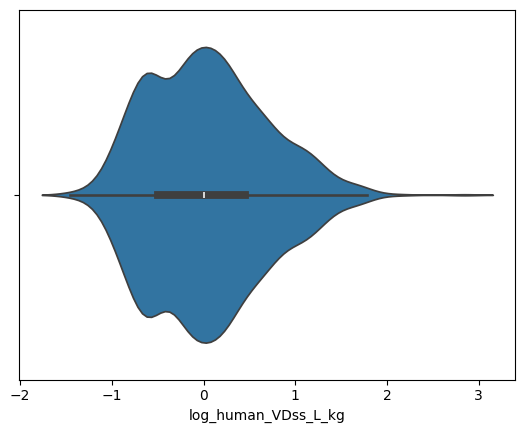

In [ ]:
sns.violinplot(x=pk_data_cleaned["log_human_VDss_L_kg"])


From this plot, we can see that most of the log VDss values fall around ~0 and span from ~-1.5 to ~2.8.

We can also use the `describe` function to summarise the pChEMBL value distribution:

In [ ]:
pk_data_cleaned.describe()

,index,log_human_VDss_L_kg
count,1249.000000,1249.000000
mean,641.200160,0.036031
std,370.217939,0.640110
min,0.000000,-1.455932
25%,321.000000,-0.494850
50%,639.000000,0.000000
75%,963.000000,0.447158
max,1282.000000,2.845098


### Featurisation

Now that the data is clean, we can generate our features.

In this exercise, we will use the RDKit descriptors to featurise our compounds. The following code assigns a list of available descriptors to the variable 'descriptor_names' and prints the length of the list.

In [ ]:
from rdkit.Chem import Descriptors

# get list of all available Descriptors
descriptors_list = [x[0] for x in Descriptors._descList]
print(len(descriptors_list))

210


Let's take a selection of descriptors and use them for modelling. For this exercise we will use a subset of 78 descriptors used in this NCATS article https://pubs.acs.org/doi/10.1021/acs.jcim.0c00884


In [ ]:
chosen_descriptors = [
    "MolLogP", "MolWt", "TPSA", "LabuteASA", "HeavyAtomMolWt", "ExactMolWt",
    "NumHAcceptors", "NumHDonors", "NumRotatableBonds", "NumHeteroatoms",
    "HeavyAtomCount", "NHOHCount", "NOCount", "NumAliphaticCarbocycles",
    "NumAliphaticHeterocycles", "NumAliphaticRings", "NumAromaticCarbocycles",
    "NumAromaticHeterocycles", "NumAromaticRings", "NumSaturatedCarbocycles",
    "NumSaturatedHeterocycles", "NumSaturatedRings", "RingCount",
    "FractionCSP3", "Chi0v", "Chi1v", "Chi2v", "Chi3v", "Chi4v", "Chi1n",
    "Chi2n", "Chi3n", "Chi4n", "HallKierAlpha", "Kappa1", "Kappa2", "Kappa3",
    "SlogP_VSA1", "SlogP_VSA2", "SlogP_VSA3", "SlogP_VSA4", "SlogP_VSA5",
    "SlogP_VSA6", "SlogP_VSA7", "SlogP_VSA8", "SlogP_VSA9", "SlogP_VSA10",
    "SlogP_VSA11", "SlogP_VSA12", "SMR_VSA1", "SMR_VSA2", "SMR_VSA3", "SMR_VSA4",
    "SMR_VSA5", "SMR_VSA6", "SMR_VSA7", "SMR_VSA8", "SMR_VSA9", "SMR_VSA10",
    "PEOE_VSA1", "PEOE_VSA2", "PEOE_VSA3", "PEOE_VSA4", "PEOE_VSA5", "PEOE_VSA6",
    "PEOE_VSA7", "PEOE_VSA8", "PEOE_VSA9", "PEOE_VSA10", "PEOE_VSA11", "PEOE_VSA12",
    "PEOE_VSA13", "PEOE_VSA14"
]

Next, we need to set up a calculator to calculate the descriptors. The ML.Descriptors module has a MolecularDescriptorsCalculator to achieve this.

In [ ]:
from rdkit.ML.Descriptors import MoleculeDescriptors
calc = MoleculeDescriptors.MolecularDescriptorCalculator(chosen_descriptors)

Once the calc variable is set up, we can calculate all descriptors for a given SMILES string like so:

In [ ]:
from rdkit import Chem
mol = Chem.MolFromSmiles('CC1=CC(=C(C=C1NC(=O)C2=C(C(=CC(=C2)I)I)O)Cl)C(C#N)C3=CC=C(C=C3)Cl')
ds = calc.CalcDescriptors(mol)
print(ds)
print(len(ds))

(7.124400000000003, 663.0799999999998, 73.12, 211.0337664023786, 648.9679999999996, 661.852179048, 3, 2, 4, 8, 30, 2, 4, 0, 0, 0, 3, 0, 3, 0, 0, 0, 3, 0.09090909090909091, 21.337540270596875, 11.567487609533984, 9.791667981874944, 6.532560560468579, 5.210790706092031, 8.654060372339206, 6.540209173088069, 4.508130316967467, 2.9673141998441293, -1.5399999999999987, 23.130028268670063, 9.726157452179187, 5.018674352279847, 5.316788604006331, 11.013707124192212, 0.0, 25.395214609352177, 32.9662491970212, 48.53093654769288, 10.045266627482652, 0.0, 0.0, 5.687386274683562, 5.749511833283905, 68.38362103460115, 9.901064578912528, 5.261891554738487, 0.0, 0.0, 12.841643245852017, 5.316788604006331, 87.97037368409433, 0.0, 11.818733146076179, 79.97818703863621, 10.423315998847038, 4.794537184071822, 0.0, 5.261891554738487, 0.0, 41.40098098584986, 99.12766827122579, 19.30283517323161, 21.120761121716058, 5.749511833283905, 0.0, 0.0, 5.907179729351506, 0.0)
73


Let's iterate over each SMILES string in our dataset and return the descriptors. We will use paralellisation to speed this up

In [ ]:
def descriptors_from_smiles(smi):
  mol = Chem.MolFromSmiles(smi)
  desc = calc.CalcDescriptors(mol)
  return list(desc)

from joblib import Parallel, delayed
all_smiles = pk_data_cleaned['smiles_r'].tolist()
all_descriptors = Parallel(n_jobs=-1, prefer='threads')(delayed(descriptors_from_smiles)(smi) for smi in all_smiles)

Now we want the descriptors in the format of a DataFrame for Machine Learning, where each row is a data point (compound) and each column is a descriptor. To do this, we just call pd.DataFrame on the list of calculated descriptors, and each item in the list will be transformed into a row of the DataFrame.

In [ ]:
desc_df = pd.DataFrame(all_descriptors)
desc_df.head()

,0,1,2,3,4,5,6,7,8,9,...,63,64,65,66,67,68,69,70,71,72
0,-1.68780,475.465,212.96,199.365020,454.297,475.161514,11,3,10,12,...,12.343784,12.132734,36.958650,23.871484,23.901918,0.000000,16.981741,5.948339,5.90718,0.000000
1,4.34140,299.434,40.13,134.495574,272.218,299.201654,2,0,4,2,...,18.093296,41.542423,40.510440,18.405095,0.000000,0.000000,5.783245,0.000000,0.00000,0.000000
2,-0.42876,529.512,169.30,221.207637,507.336,529.176450,9,1,10,13,...,6.423350,17.811206,67.598190,23.442771,24.119354,5.817221,5.559267,0.000000,5.90718,0.000000
3,0.76550,188.294,4.44,86.745057,170.150,188.143376,0,1,4,1,...,6.423350,30.331835,18.407623,6.420822,13.089513,6.544756,0.000000,0.000000,0.00000,0.000000
4,-2.55960,267.241,130.83,107.626319,254.137,267.085521,8,4,2,8,...,6.423350,5.920434,6.066367,6.196844,6.606882,18.025796,11.828952,0.000000,0.00000,5.689743


To understand feature importance later, we need to set the DataFrame column names to correspond to each descriptor. Since we already have the descriptor names stored in a list, we assign the .columns attribute of the DataFrame to the list.

In [ ]:
desc_df.columns = chosen_descriptors
desc_df.head()

,MolLogP,MolWt,TPSA,LabuteASA,HeavyAtomMolWt,ExactMolWt,NumHAcceptors,NumHDonors,NumRotatableBonds,NumHeteroatoms,...,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,PEOE_VSA14
0,-1.68780,475.465,212.96,199.365020,454.297,475.161514,11,3,10,12,...,12.343784,12.132734,36.958650,23.871484,23.901918,0.000000,16.981741,5.948339,5.90718,0.000000
1,4.34140,299.434,40.13,134.495574,272.218,299.201654,2,0,4,2,...,18.093296,41.542423,40.510440,18.405095,0.000000,0.000000,5.783245,0.000000,0.00000,0.000000
2,-0.42876,529.512,169.30,221.207637,507.336,529.176450,9,1,10,13,...,6.423350,17.811206,67.598190,23.442771,24.119354,5.817221,5.559267,0.000000,5.90718,0.000000
3,0.76550,188.294,4.44,86.745057,170.150,188.143376,0,1,4,1,...,6.423350,30.331835,18.407623,6.420822,13.089513,6.544756,0.000000,0.000000,0.00000,0.000000
4,-2.55960,267.241,130.83,107.626319,254.137,267.085521,8,4,2,8,...,6.423350,5.920434,6.066367,6.196844,6.606882,18.025796,11.828952,0.000000,0.00000,5.689743


Now we have our features in the correct format for modelling!

When calculating descriptors its possible that some calculations will fail, resulting in null values for some compound-descriptor combinations. To remove columns where there are null values present in any row, we can use dropna again. This time, we pass axis=1 to indicate that we want to drop columns, not rows.

In [ ]:
desc_df = desc_df.dropna(axis=1,how='any')
desc_df.shape

(1249, 73)

0 descriptors were dropped due to null values.

### Model training

Now we have cleaned the data and calculated our descriptors, we can proceed with modelling.

Let's start with performing a train-test split. We first need our pChEMBL values in the form of a 1D array.

In [ ]:
pk_array = np.ravel(pk_data_cleaned['log_human_VDss_L_kg'].values)
pk_array

array([ 0.00646604,  1.07918125, -0.27572413, ...,  0.61278386,
        0.59106461,  0.51851394])

Now we can use `train_test_split` to define our X_train, y_train, X_test and y_test. Let's use an 80:20 split.

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(desc_df, pk_array, test_size=0.2, random_state=42)

Now we have split the data, we can train a Random Forest Regressor. Warning: This takes a moment to run!

In [ ]:
from sklearn.ensemble import RandomForestRegressor
reg = RandomForestRegressor(n_jobs=-1)
reg.fit(X_train,y_train)

RandomForestRegressor(n_jobs=-1)

Next, we apply the model to the test dataset descriptors (X_test) and store the results in a variable called y_pred.

In [ ]:
y_pred = reg.predict(X_test)
y_pred.shape

(250,)

How well has our model performed? Let's calculate the r2 and mean absolute error

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error
r2 = r2_score(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)

print(r2)
print(mae)

0.4017593820343618
0.3869703466343044


The model has an r2 score of 0.40 and a mean absolute error of 0.39

Let's visualise the true vs the predicted values.

<Axes: xlabel='True', ylabel='Predicted'>

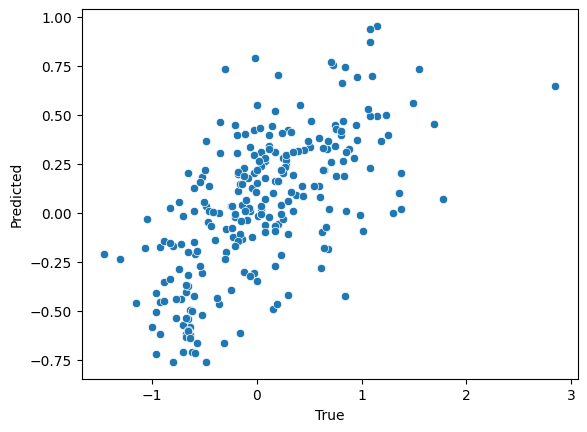

In [ ]:
import seaborn as sns
pred_df = pd.DataFrame(
    {'True': y_test,
     'Predicted': y_pred
    })
sns.scatterplot(data=pred_df, x="True", y="Predicted")

Model performance can be improved using hyperparameter optimisation. We will cover this in the next exercise

### Model interpretation

We can interpret the model in a number of ways. Here we will use SHAP values to understand the contribution of each feature to the model.

To do this, we use the shap library. The TreeExplainer is fit using the trained model, and the shap values are computed for the test set. Finally, a summary plot is created. Warning: Takes some time to compute Shap values

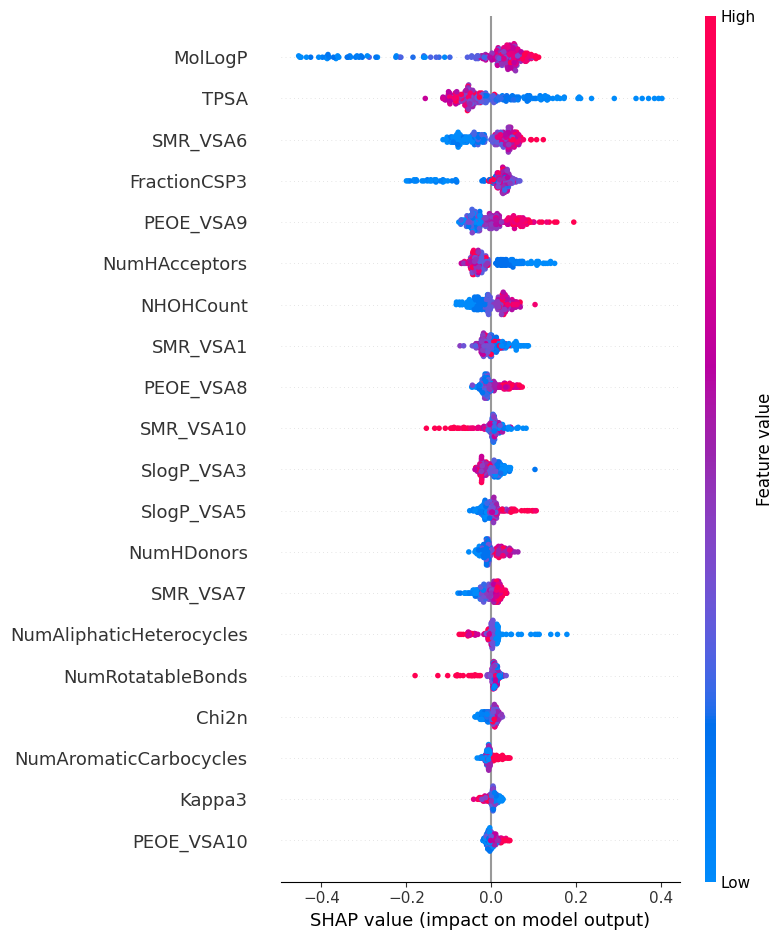

In [ ]:
import shap

# explain all the predictions in the test set
explainer = shap.Explainer(reg, random_state=42))
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

The most important features are TPSA and LogP. As the value of logP increases the predicted VDss increases too.

LogP measures the compound's hydrophobicity, indicating how well it dissolves in fats versus water. A higher logP suggests greater lipophilicity, meaning the compound is more likely to partition into lipid-rich tissues (like adipose tissue or cell membranes).

As logP increases, the compound can more readily cross cell membranes and distribute into peripheral tissues, leading to a higher VDss.

In other words, more lipophilic compounds distribute extensively into tissues, increasing the overall volume of distribution, as they do not remain confined to the bloodstre

Now you have succesfully trained a PK prediction model and visualised the feature importance!

## Exercise 2: Classification modelling Clearance with Morgan Fingerprints


We will now look at a classification task. We will try to predict if a compound has a high clearnace using chemical structure. The chemical structure is represented by bit vector of Morgan Fingerprints.

For this purpose we will follow the steps below in order

1. Load the dataset
2. Standardise smiles
3. Generate Fingerprints
4. Split data into train and test
6. Hyperparamter optimisation of Random Forest model using training data
6. Evaluate on test data

### Load the dataset

In [ ]:
import rdkit
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("Lombardo_Human_PK_parameters.csv")[["smiles_r", "human_CL_mL_min_kg"]]
df

,smiles_r,human_CL_mL_min_kg
0,C#CCC(Cc1cnc2nc(N)nc(N)c2n1)c1ccc(C(=O)NC(CCC(...,4.35
1,C#CCCCC(=O)c1cc(C(C)(C)C)c([O-])c(C(C)(C)C)c1,8.90
2,C#CCN(Cc1cc2c(=O)nc(C)[n-]c2cc1C)c1ccc(C(=O)NC...,0.29
3,C#CC[NH+](C)C(C)Cc1ccccc1,20.00
4,C#C[C@@]1(O)[C@@H](CO)O[C@H](n2ccc(N)nc2=O)[C@...,1.60
...,...,...
1278,c1cc2c(c(N3CC[NH2+]CC3)c1)OCCO2,8.00
1279,c1ccc(C2([NH+]3CCCCC3)CCCCC2)cc1,5.10
1280,c1ccc(C2(c3ccccc3)CC2C2=[NH+]CCN2)cc1,8.60
1281,c1ccc(CN(CC2=[NH+]CCN2)c2ccccc2)cc1,19.67


In [ ]:
df["Low_Clearnace_binary"] = df["human_CL_mL_min_kg"].apply(lambda x: 1 if x < 5 else 0)
df

,smiles_r,human_CL_mL_min_kg,Clearnace_binary,Low_Clearnace_binary
0,C#CCC(Cc1cnc2nc(N)nc(N)c2n1)c1ccc(C(=O)NC(CCC(...,4.35,0,1
1,C#CCCCC(=O)c1cc(C(C)(C)C)c([O-])c(C(C)(C)C)c1,8.90,1,0
2,C#CCN(Cc1cc2c(=O)nc(C)[n-]c2cc1C)c1ccc(C(=O)NC...,0.29,0,1
3,C#CC[NH+](C)C(C)Cc1ccccc1,20.00,1,0
4,C#C[C@@]1(O)[C@@H](CO)O[C@H](n2ccc(N)nc2=O)[C@...,1.60,0,1
...,...,...,...,...
1278,c1cc2c(c(N3CC[NH2+]CC3)c1)OCCO2,8.00,1,0
1279,c1ccc(C2([NH+]3CCCCC3)CCCCC2)cc1,5.10,1,0
1280,c1ccc(C2(c3ccccc3)CC2C2=[NH+]CCN2)cc1,8.60,1,0
1281,c1ccc(CN(CC2=[NH+]CCN2)c2ccccc2)cc1,19.67,1,0


value_counts() shows us the number of datapoints in each class of the dataset, in this case, 627 low clearance compounds and 656 medium-high clearance compounds.

In [ ]:
df.Clearnace_binary.value_counts()

,count
Clearnace_binary,
0,656
1,627


### Standardise SMILES

standardize(), performs various standardisation functions to return a standardised smiles.This includes deprotonation, normalisation, reionisation, neutralisation, tautomer canonicalisation etc.

The try, except combination allows for error handling, and returns "Cannot_do" if the functions fail for a particular molecule.

In [ ]:
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit.Chem import inchi
from rdkit import Chem

def standardize(smiles):
    # follows the steps in
    # https://github.com/greglandrum/RSC_OpenScience_Standardization_202104/blob/main/MolStandardize%20pieces.ipynb
    # as described **excellently** (by Greg) in
    # https://www.youtube.com/watch?v=eWTApNX8dJQ
    try:
        mol = Chem.MolFromSmiles(smiles)

        # removeHs, disconnect metal atoms, normalize the molecule, reionize the molecule
        clean_mol = rdMolStandardize.Cleanup(mol)

        # if many fragments, get the "parent" (the actual mol we are interested in)
        parent_clean_mol = rdMolStandardize.FragmentParent(clean_mol)

        # try to neutralize molecule
        uncharger = rdMolStandardize.Uncharger() # annoying, but necessary as no convenience method exists
        uncharged_parent_clean_mol = uncharger.uncharge(parent_clean_mol)

        # note that no attempt is made at reionization at this step
        # nor at ionization at some pH (rdkit has no pKa caculator)
        # the main aim to to represent all molecules from different sources
        # in a (single) standard way, for use in ML, catalogue, etc.

        te = rdMolStandardize.TautomerEnumerator() # idem
        taut_uncharged_parent_clean_mol = te.Canonicalize(uncharged_parent_clean_mol)

        return  Chem.MolToSmiles(taut_uncharged_parent_clean_mol)

    except:

        return "Cannot_do"



We apply both these functions to the respective columns in the dataframe. First standardised_smile_from_inchi() converts InChICode_standardised to smiles. Then the second function standardize() converts smiles to smiles_r.

In [ ]:
df["smiles_r"] = df["smiles_r"].apply(standardize)
df

Streaming output truncated to the last 5000 lines.
[21:42:48] Initializing MetalDisconnector
[21:42:48] Running MetalDisconnector
[21:42:48] Initializing Normalizer
[21:42:48] Running Normalizer
[21:42:48] Running LargestFragmentChooser
[21:42:48] Running Uncharger
[21:42:48] Removed positive charge.
[21:42:48] Initializing MetalDisconnector
[21:42:48] Running MetalDisconnector
[21:42:48] Initializing Normalizer
[21:42:48] Running Normalizer
[21:42:48] Initializing MetalDisconnector
[21:42:48] Running MetalDisconnector
[21:42:48] Initializing Normalizer
[21:42:48] Running Normalizer
[21:42:48] Running LargestFragmentChooser
[21:42:48] Running Uncharger
[21:42:48] Removed positive charge.
[21:42:48] Initializing MetalDisconnector
[21:42:48] Running MetalDisconnector
[21:42:48] Initializing Normalizer
[21:42:48] Running Normalizer
[21:42:48] Initializing MetalDisconnector
[21:42:48] Running MetalDisconnector
[21:42:48] Initializing Normalizer
[21:42:48] Running Normalizer
[21:42:48] Runn

,smiles_r,human_CL_mL_min_kg,Clearnace_binary,Low_Clearnace_binary
0,C#CCC(Cc1cnc2nc(N)nc(N)c2n1)c1ccc(C(=O)NC(CCC(...,4.35,0,1
1,C#CCCCC(=O)c1cc(C(C)(C)C)c(O)c(C(C)(C)C)c1,8.90,1,0
2,C#CCN(Cc1cc2c(=O)[nH]c(C)nc2cc1C)c1ccc(C(=O)NC...,0.29,0,1
3,C#CCN(C)C(C)Cc1ccccc1,20.00,1,0
4,C#C[C@@]1(O)[C@@H](CO)O[C@H](n2ccc(N)nc2=O)[C@...,1.60,0,1
...,...,...,...,...
1278,c1cc2c(c(N3CCNCC3)c1)OCCO2,8.00,1,0
1279,c1ccc(C2(N3CCCCC3)CCCCC2)cc1,5.10,1,0
1280,c1ccc(C2(c3ccccc3)CC2C2=NCCN2)cc1,8.60,1,0
1281,c1ccc(CN(CC2=NCCN2)c2ccccc2)cc1,19.67,1,0


Next we remove compounds for which standardisation of smiles failed!

In [ ]:
df = df[df["smiles_r"]!="Cannot_do"].reset_index(drop=True)


There maybe duplicates here, where the same standardised SMILES may have different activity. For example, sodium salt of benzoic acid and benzoic acid have the same standardised SMILES (bacause we remove salts during standardisation). In that case, we look for evidence of activity and if either compound was toxic, we mark the standardised SMILES as toxic.

In [ ]:
df = df.sort_values(by="Low_Clearnace_binary", ascending=False).reset_index(drop=True)
df

,smiles_r,human_CL_mL_min_kg,Clearnace_binary,Low_Clearnace_binary
0,C#CCC(Cc1cnc2nc(N)nc(N)c2n1)c1ccc(C(=O)NC(CCC(...,4.35,0,1
1,CC(C)(C)NCC(O)c1cc(O)cc(O)c1,3.40,0,1
2,N=C(N)NC(CS)C(=O)O,2.88,0,1
3,N=C(N)NCCCC(NC(=O)C1CCCN1C(=O)C1CSSCCC(=O)NC(C...,1.40,0,1
4,N=C(N)NCCCC1NC(=O)CCSSCC(C(N)=O)NC(=O)C2CCCN2C...,2.88,0,1
...,...,...,...,...
1278,OCc1ncc2n1-c1ccc(Cl)cc1C(c1ccccc1F)=NC2,9.71,1,0
1279,CC(C)CC(NC(=O)C(CCc1ccccc1)NC(=O)CN1CCOCC1)C(=...,39.50,1,0
1280,CC(C)C1NC(=O)C(CCCCN)NC(=O)C(Cc2c[nH]c3ccccc23...,5.70,1,0
1281,CC(C)C(=O)OCC(=O)[C@]12O[C@@H](C3CCCCC3)O[C@@H...,33.30,1,0


Look at the code above, we have sorted it by activity. Below, you will see, we dropped the duplicates, and among all duplicates, we kept the one that appears aboce in the dataset (which should be the toxic compound if any)

In [ ]:
df = df.drop_duplicates(subset=["smiles_r"], keep="first").reset_index(drop=True)
df

,smiles_r,human_CL_mL_min_kg,Clearnace_binary,Low_Clearnace_binary
0,C#CCC(Cc1cnc2nc(N)nc(N)c2n1)c1ccc(C(=O)NC(CCC(...,4.35,0,1
1,CC(C)(C)NCC(O)c1cc(O)cc(O)c1,3.40,0,1
2,N=C(N)NC(CS)C(=O)O,2.88,0,1
3,N=C(N)NCCCC(NC(=O)C1CCCN1C(=O)C1CSSCCC(=O)NC(C...,1.40,0,1
4,N=C(N)NCCCC1NC(=O)CCSSCC(C(N)=O)NC(=O)C2CCCN2C...,2.88,0,1
...,...,...,...,...
1278,OCc1ncc2n1-c1ccc(Cl)cc1C(c1ccccc1F)=NC2,9.71,1,0
1279,CC(C)CC(NC(=O)C(CCc1ccccc1)NC(=O)CN1CCOCC1)C(=...,39.50,1,0
1280,CC(C)C1NC(=O)C(CCCCN)NC(=O)C(Cc2c[nH]c3ccccc23...,5.70,1,0
1281,CC(C)C(=O)OCC(=O)[C@]12O[C@@H](C3CCCCC3)O[C@@H...,33.30,1,0


We are now therefore left with 6433 compounds in this dataset.

In [ ]:
df.Low_Clearnace_binary.value_counts()

,count
Low_Clearnace_binary,
1,650
0,633


### Generate Fingerprints

Next, we will generate Morgan fingerprints for all compounds in the dataset. So we first create Mol objeects for each smiles

In [ ]:
Ser_Mol = df['smiles_r'].apply(Chem.MolFromSmiles)



The rdkit package has a function to generate Morgan Fingerprint As Bit Vector. We will first import the function

In [ ]:
from rdkit.Chem.rdMolDescriptors import GetMorganFingerprintAsBitVect

The cell below uses the function from rdkit to generate morgan fingerprints. The length of the fingerprints is 2048 bits, so each molecule has 2048 binary digits corresponding to substructures that may be present in that compound. These binary bit vectors are used as features in the model.

In [ ]:
Morgan_fingerprint= Ser_Mol.apply(GetMorganFingerprintAsBitVect, args=(2, 2048))

df["Morgan_fingerprint"] =Morgan_fingerprint
df

[22:24:38] DEPRECATION WARNING: please use MorganGenerator
[22:24:38] DEPRECATION WARNING: please use MorganGenerator
[22:24:38] DEPRECATION WARNING: please use MorganGenerator
[22:24:38] DEPRECATION WARNING: please use MorganGenerator
[22:24:38] DEPRECATION WARNING: please use MorganGenerator
[22:24:38] DEPRECATION WARNING: please use MorganGenerator
[22:24:38] DEPRECATION WARNING: please use MorganGenerator
[22:24:38] DEPRECATION WARNING: please use MorganGenerator
[22:24:38] DEPRECATION WARNING: please use MorganGenerator
[22:24:38] DEPRECATION WARNING: please use MorganGenerator
[22:24:38] DEPRECATION WARNING: please use MorganGenerator
[22:24:38] DEPRECATION WARNING: please use MorganGenerator
[22:24:38] DEPRECATION WARNING: please use MorganGenerator
[22:24:38] DEPRECATION WARNING: please use MorganGenerator
[22:24:38] DEPRECATION WARNING: please use MorganGenerator
[22:24:38] DEPRECATION WARNING: please use MorganGenerator
[22:24:38] DEPRECATION WARNING: please use MorganGenerat

,smiles_r,human_CL_mL_min_kg,Clearnace_binary,Low_Clearnace_binary,Morgan_fingerprint
0,C#CCC(Cc1cnc2nc(N)nc(N)c2n1)c1ccc(C(=O)NC(CCC(...,4.35,0,1,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,CC(C)(C)NCC(O)c1cc(O)cc(O)c1,3.40,0,1,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,N=C(N)NC(CS)C(=O)O,2.88,0,1,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,N=C(N)NCCCC(NC(=O)C1CCCN1C(=O)C1CSSCCC(=O)NC(C...,1.40,0,1,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,N=C(N)NCCCC1NC(=O)CCSSCC(C(N)=O)NC(=O)C2CCCN2C...,2.88,0,1,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
...,...,...,...,...,...
1278,OCc1ncc2n1-c1ccc(Cl)cc1C(c1ccccc1F)=NC2,9.71,1,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1279,CC(C)CC(NC(=O)C(CCc1ccccc1)NC(=O)CN1CCOCC1)C(=...,39.50,1,0,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1280,CC(C)C1NC(=O)C(CCCCN)NC(=O)C(Cc2c[nH]c3ccccc23...,5.70,1,0,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1281,CC(C)C(=O)OCC(=O)[C@]12O[C@@H](C3CCCCC3)O[C@@H...,33.30,1,0,"[0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


Here we create names for the features: Mfp0, Mfp1 through to Mfp2047.

In [ ]:
Morgan_featurenames  = []
for x in range(0,2048):
    x = "Mfp"+str(x)
    Morgan_featurenames.append(x)

The cell below explains which variable/df is used for what in a ML model.

We are using the dataframe df, where the features which the ML model learns from is stored in the column "Morgan_fingerprint" and endpoints which is to be predicted is stored in the column "Activity".

In [ ]:
data = df
features = "Morgan_fingerprint"
endpoint="Low_Clearnace_binary"

print(endpoint)

X = np.array([x for x in df['Morgan_fingerprint']])
y = data[endpoint]

Low_Clearnace_binary


Here X are the featrures and they are binary. Look at the shape of this ndarrary.

There are 6432 compounds in total and each compounds has 2048 features.

In [ ]:
X

array([[0, 1, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       ...,
       [0, 1, 0, ..., 0, 0, 0],
       [0, 1, 1, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [ ]:
X.shape

(1283, 2048)

The same can be seen in y, each compound is associated to an activity.

In [ ]:
y

,Low_Clearnace_binary
0,1
1,1
2,1
3,1
4,1
...,...
1278,0
1279,0
1280,0
1281,0


In [ ]:
y.shape

(1283,)

### Split data into training and test data

Now for training a model we muyst split our dataset into train and test. This time we have a classification task. So we must ensure the _distribution_ of classes (toxic and non-toxic)remain same in both test and train.

Note the keywords here:

stratify: this means the splitting will make sure each of train and test dataset contains same proportion of both the classes.

test_size: We have selected 25% of the data to be in the test set and 75% of the data in the training dataset

random_state: Finally, this splitting will happen randomly. But to ensure this split is same for all of use, we have set a random_state. If you feel adventurous, do go ahead and change this 42 to another number. Everything will remain the same except you might find results will vary a litte.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

Our splitting is now complete. The function has split our training data (962 compounds) and test data (321 compounds)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(962, 2048)
(321, 2048)
(962,)
(321,)


of which the train dat contains 487 low clearance compounds and test data contains 163 compounds. Can you check if this is the same ratio  to each other and the original data?

In [ ]:
y_train.value_counts()

,count
Low_Clearnace_binary,
1,487
0,475


In [ ]:
y_test.value_counts()

,count
Low_Clearnace_binary,
1,163
0,158


### Hyperparamter optimisation of Random Forest model using training data

We are going to use a Random Forest Classifier to classify mitochondiral toxicty. We will perform a 5 fold grid search cross validation to optimise the parameters of the Classifier.

We can choose between 200 and 300 trees, maximum features to be used in these trees, the minimum samples to split a node, the masimum depth of a tree.

The taining data will be split into 5 groups and 4 of these will be trained on models varying these parameters. This will be repeated 5 times and the best performing model's parameters are stored in the best_estimator_.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state = 42, n_jobs=-1)

param_grid = {
            "n_estimators": [200,300],
            "max_features": ["sqrt", "log2"],
            "min_samples_split": [2,4],
            "max_depth": [3, 5],
            "bootstrap": [True],
            'n_jobs': [-1],
            "class_weight": ["balanced"]
            }

gsh = GridSearchCV(estimator = rf, param_grid = param_grid, cv = 5, n_jobs=-1, verbose = 1)


In [ ]:
##MODELS
print(f"Running ____________________{endpoint} MODELS")

gsh.fit(X_train, y_train)
#print(gsh.best_estimator_)

#HeldOutTest
classifier = gsh.best_estimator_

Running ____________________Low_Clearnace_binary MODELS
Fitting 5 folds for each of 16 candidates, totalling 80 fits


So this is the best model that will now be trained on the entire training data.

In [ ]:
classifier.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=5,
                       max_features='log2', n_estimators=300, n_jobs=-1,
                       random_state=42)

### Evaluate on test data

We will now evaluate our model on the test data and predict the outcome and an associated probability.

The default thrshold is 0.50

If the proba is more than 0.50, the prediction is true (toxic), else false (non-toxic)

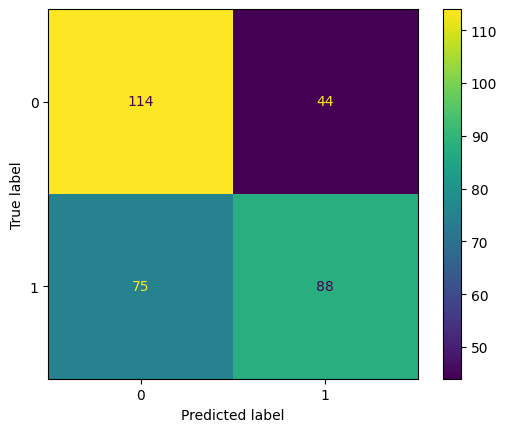

In [ ]:
from sklearn.metrics import matthews_corrcoef,confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score, balanced_accuracy_score
from sklearn.metrics import average_precision_score


y_prob= classifier.predict_proba(X_test)[:,1]
y_pred = classifier.predict(X_test)

conf_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix,
                           display_labels=classifier.classes_).plot()
plt.show()


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.60      0.72      0.66       158
           1       0.67      0.54      0.60       163

    accuracy                           0.63       321
   macro avg       0.63      0.63      0.63       321
weighted avg       0.64      0.63      0.63       321



This is the balanced accuracy (balanced for each class)



In [ ]:
ba= balanced_accuracy_score(y_test, y_pred)
print('balanced_accuracy_score ',ba)

balanced_accuracy_score  0.6306981439776345


The Matthews correlation coefficient is used in machine learning as a measure of the quality of binary and multiclass classifications. It takes into account true and false positives and negatives and is generally regarded as a balanced measure which can be used even if the classes are of very different sizes. The MCC is in essence a correlation coefficient value between -1 and +1. A coefficient of +1 represents a perfect prediction, 0 an average random prediction and -1 an inverse prediction. The statistic is also known as the phi coefficient.

In [ ]:
mcc=matthews_corrcoef(y_test, y_pred)
print('matthews_corrcoef ',mcc)

matthews_corrcoef  0.2655852147120469


Sensitivity and specificity mathematically describe the accuracy of a test which reports the presence or absence of a condition. Individuals for which the condition is satisfied are considered "positive" and those for which it is not are considered "negative".

Sensitivity (true positive rate) refers to the probability of a positive test, conditioned on truly being positive.

Specificity (true negative rate) refers to the probability of a negative test, conditioned on truly being negative.

In [ ]:
# Sensitivity, hit rate, recall, or true positive rate
Specificity = conf_matrix[0,0]/(conf_matrix[0,0]+conf_matrix[0,1])

In [ ]:
# Specificity or true negative rate
Sensitivity = conf_matrix[1,1]/(conf_matrix[1,0]+conf_matrix[1,1])
print( 'Sensitivity', Sensitivity)
print( 'Specificity', Specificity)



Sensitivity 0.5398773006134969
Specificity 0.7215189873417721


The F1 score can be interpreted as a harmonic mean of the precision and recall, where an F1 score reaches its best value at 1 and worst score at 0. The relative contribution of precision and recall to the F1 score are equal. The formula for the F1 score is:

F1 = 2 * (precision * recall) / (precision + recall)



In [ ]:
f1= f1_score(y_test, y_pred, average='binary')
print('F1 Toxic', f1)

F1 Toxic 0.5966101694915255


A receiver operating characteristic (ROC), or simply ROC curve, is a graphical plot which illustrates the performance of a binary classifier system as its discrimination threshold is varied. It is created by plotting the fraction of true positives out of the positives (TPR = true positive rate) vs. the fraction of false positives out of the negatives (FPR = false positive rate), at various threshold settings. TPR is also known as sensitivity, and FPR is one minus the specificity or true negative rate.

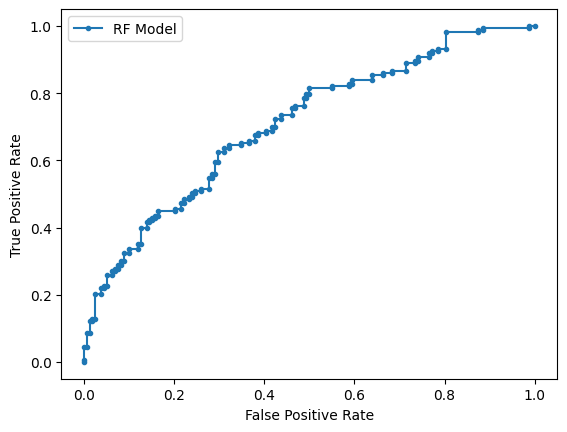

AUC-ROC  0.7075405762211696


In [ ]:
# calculate roc curves
best_model_fpr, best_model_tpr, _ = roc_curve(y_test, y_prob)
plt.plot(best_model_fpr, best_model_tpr, marker='.', label='RF Model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

AUC = roc_auc_score(y_test, y_prob)
print('AUC-ROC ',AUC)


In [ ]:
classifier

RandomForestClassifier(class_weight='balanced', max_depth=5,
                       max_features='log2', n_estimators=300, n_jobs=-1,
                       random_state=42)

In [ ]:
!pip install dtreeviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 4.6 MB/s eta 0:00:00


So what does it look like... the Random forest? Well its composed of various trees and this is the first one shown below:

In [ ]:
import dtreeviz

random_state = 42

viz = dtreeviz.model(classifier.estimators_[0], X_train.astype(int), y_train.astype(int),
               target_name="endpoint",
               feature_names=Morgan_featurenames,
               class_names=["Non-Toxic", "Toxic"])



See how the tree splits based on certain bits and ultimately leads to nodes. Each leaf node is then assigned a class. The Random Forest works on the wisdom of the crowd, or average voting of all the trees.

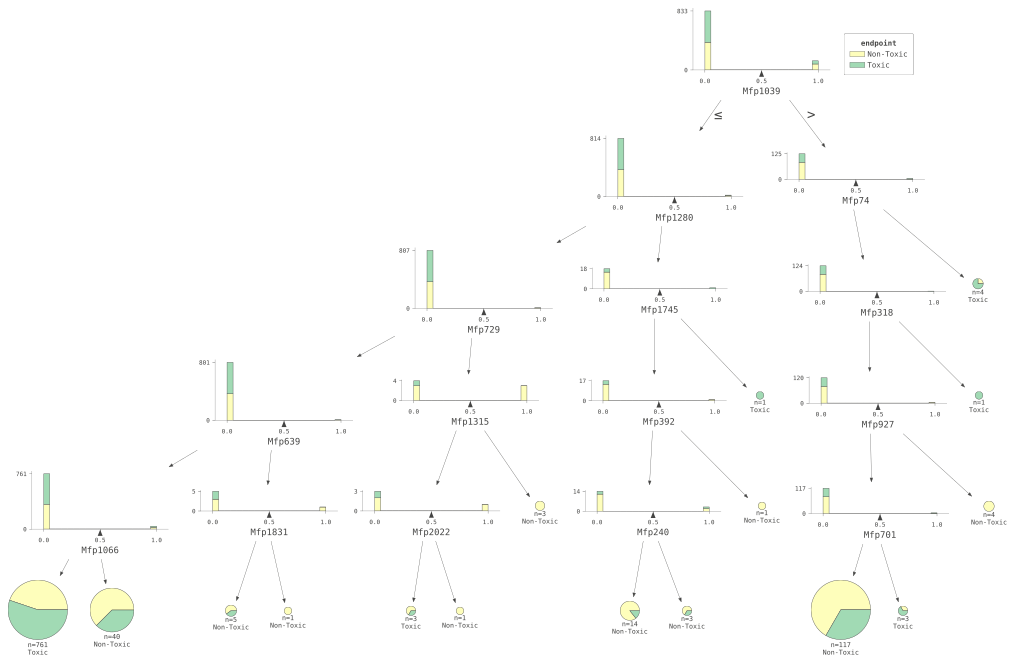

In [ ]:
viz.view(fontname="monospace")

### Feature Importances

Finally, we evaluate the importance of features on the classification task. The blue bars are the feature importances of the forest.

Feature importances are provided by the fitted attribute feature_importances_ and they are computed as the meanof accumulation of the impurity decrease within each tree.

In [ ]:
importances = classifier.feature_importances_
#std = np.std([tree.feature_importances_ for tree in classifier.estimators_], axis=0)
importances

array([0.00000000e+00, 6.23351803e-04, 2.44742118e-03, ...,
       6.31220205e-04, 2.29226845e-05, 4.64892729e-04])

In [ ]:
forest_importances = pd.Series(importances, index=Morgan_featurenames)
forest_importances = forest_importances.sort_values(ascending=False)[:100]
forest_importances


,0
Mfp998,0.011009
Mfp859,0.010748
Mfp456,0.010657
Mfp650,0.008957
Mfp1922,0.008588
...,...
Mfp1495,0.002157
Mfp246,0.002136
Mfp869,0.002136
Mfp1691,0.002135


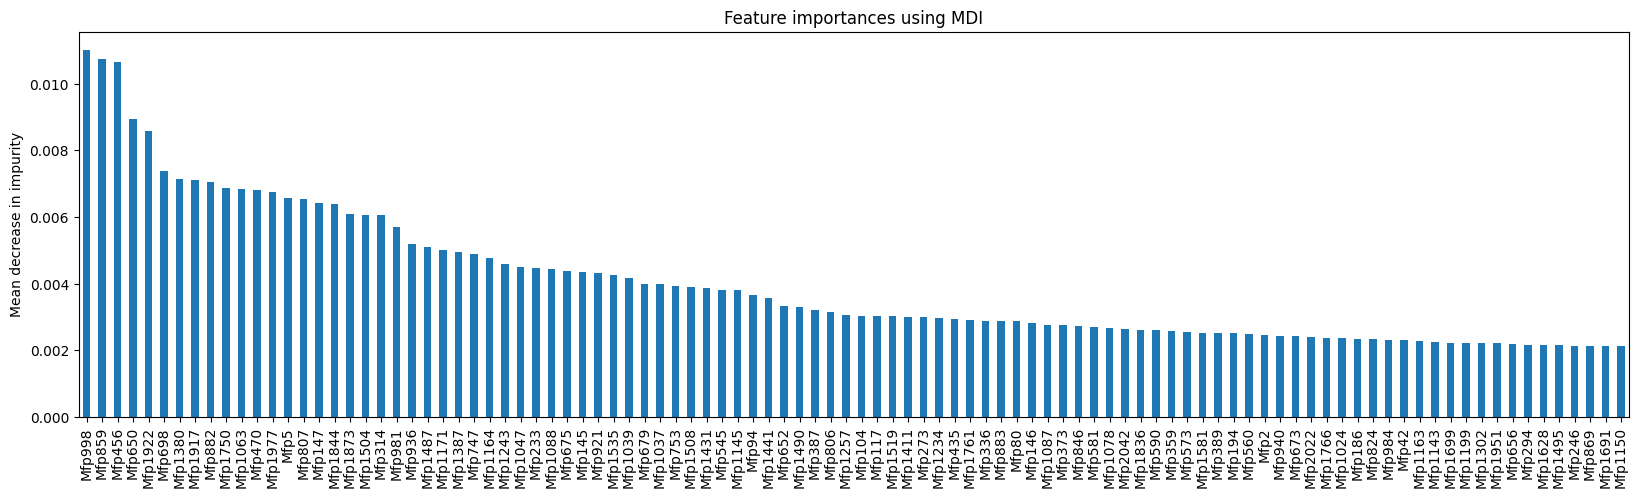

In [ ]:
#We ar eonly plotting the top 100 features here

plt.figure(figsize=(20,5), dpi=100)
forest_importances.plot.bar()
plt.title("Feature importances using MDI")
plt.ylabel("Mean decrease in impurity")
plt.show()


Thank you!

In [ ]:
## Exercise 3: Try Yourself Classification modelling Clearance with Cell Painting!


In [ ]:
CP = pd.read_csv("Cell_Painting_PK_Overlap.csv")
CP

,Unnamed: 0,smiles_r,InChIKey_14,X_1,X_2,X_3,X_4,X_5,X_6,X_7,...,X_605,X_606,X_607,X_608,X_609,X_610,X_611,X_612,X_613,X_614
0,0,C#CCC(Cc1cnc2nc(N)nc(N)c2n1)c1ccc(C(=O)NC(CCC(...,OGSBUKJUDHAQEA,0.173005,-0.055359,-0.079063,-0.063975,-0.037423,-0.132237,-0.168870,...,-0.046736,-0.032602,0.100442,-0.002973,-0.026373,0.026148,0.035308,0.047836,-0.001020,0.035980
1,1,C#C[C@@]1(O)[C@@H](CO)O[C@H](n2ccc(N)nc2=O)[C@...,JFIWEPHGRUDAJN,-0.024696,0.267927,0.047025,1.827824,-0.249123,0.012975,-0.274649,...,0.418554,-0.361095,0.176236,-0.326734,-0.616259,-0.181528,0.064462,-0.052350,-0.148733,-0.538852
2,2,C#C[C@]1(O)C=C[C@H]2[C@@H]3CC=C4CC(=O)CCC4[C@H...,PCGOZSMTJRCWQF,0.086185,0.146223,0.052145,-0.014080,0.035577,-0.003699,0.138352,...,0.042093,0.012642,0.066416,0.024186,0.093693,-0.001645,0.036896,-0.036251,0.017220,-0.020357
3,3,C#C[C@]1(O)CC[C@H]2[C@@H]3CC=C4CC(=O)CCC4[C@H]...,BOMXWTHINLWJIE,0.126815,-0.008202,0.073392,0.133006,0.033630,-0.023477,0.004710,...,0.049672,-0.039148,0.012924,-0.016941,0.034631,-0.197679,-0.110593,0.060739,0.022046,-0.037269
4,4,C#C[C@]1(O)CC[C@H]2[C@@H]3CC=C4CC(=O)CCC4[C@H]...,LYRBZVWRTAFWPO,-0.055145,0.023126,0.019212,-0.116258,0.001423,0.021460,0.070738,...,0.013182,0.039568,0.043670,0.017972,0.069196,-0.025845,0.025525,-0.013102,0.009954,-0.016386
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668,668,[O-]c1c(C2=CC[C@@H](c3ccc(Cl)cc3)CC2)c(O)c2ccc...,JAUORDHNHDCTAS,0.084492,0.001888,0.049077,-0.113930,0.039747,-0.023594,0.073202,...,0.027154,0.018506,-0.021095,0.032349,0.001211,-0.009857,-0.067028,-0.088329,0.017273,0.000560
669,669,[O-]c1cc2c(cc1[O-])[C@H](Cc1cccc3ccccc13)[NH2+...,YGCQFKVNIBDJFW,0.030968,-0.013739,0.021281,0.051973,0.101179,-0.011706,0.102847,...,-0.074609,-0.066460,-0.021806,0.051513,0.083597,0.133859,0.069455,-0.074283,0.072668,0.064094
670,670,[O-]c1ccc([C@@H](O)C[NH2+]CCCCCCOCCOCc2c(Cl)cc...,DAFYYTQWSAWIGS,-0.076603,-0.061613,0.090980,-0.012862,0.064727,0.040968,0.108275,...,-0.158372,-0.068720,-0.015692,0.035112,0.019397,0.074495,0.008692,0.073793,0.046485,0.134995
671,671,[O-]c1ccc([C@H]2C[NH2+]CCc3c2cc([O-])c([O-])c3...,TVURRHSHRRELCG,-0.033495,-0.098609,0.079632,-0.028724,0.087755,0.061851,0.138927,...,0.036277,0.000139,-0.060137,-0.013198,-0.043733,-0.051933,-0.086996,-0.102980,0.001469,-0.022447


In [ ]:
CP = CP.drop_duplicates(subset=["InChIKey_14"], keep="first").reset_index(drop=True).iloc[:, 1:]
CP

,smiles_r,InChIKey_14,X_1,X_2,X_3,X_4,X_5,X_6,X_7,X_8,...,X_605,X_606,X_607,X_608,X_609,X_610,X_611,X_612,X_613,X_614
0,C#CCC(Cc1cnc2nc(N)nc(N)c2n1)c1ccc(C(=O)NC(CCC(...,OGSBUKJUDHAQEA,0.173005,-0.055359,-0.079063,-0.063975,-0.037423,-0.132237,-0.168870,0.033926,...,-0.046736,-0.032602,0.100442,-0.002973,-0.026373,0.026148,0.035308,0.047836,-0.001020,0.035980
1,C#C[C@@]1(O)[C@@H](CO)O[C@H](n2ccc(N)nc2=O)[C@...,JFIWEPHGRUDAJN,-0.024696,0.267927,0.047025,1.827824,-0.249123,0.012975,-0.274649,-0.518228,...,0.418554,-0.361095,0.176236,-0.326734,-0.616259,-0.181528,0.064462,-0.052350,-0.148733,-0.538852
2,C#C[C@]1(O)C=C[C@H]2[C@@H]3CC=C4CC(=O)CCC4[C@H...,PCGOZSMTJRCWQF,0.086185,0.146223,0.052145,-0.014080,0.035577,-0.003699,0.138352,0.075479,...,0.042093,0.012642,0.066416,0.024186,0.093693,-0.001645,0.036896,-0.036251,0.017220,-0.020357
3,C#C[C@]1(O)CC[C@H]2[C@@H]3CC=C4CC(=O)CCC4[C@H]...,BOMXWTHINLWJIE,0.126815,-0.008202,0.073392,0.133006,0.033630,-0.023477,0.004710,-0.050944,...,0.049672,-0.039148,0.012924,-0.016941,0.034631,-0.197679,-0.110593,0.060739,0.022046,-0.037269
4,C#C[C@]1(O)CC[C@H]2[C@@H]3CC=C4CC(=O)CCC4[C@H]...,LYRBZVWRTAFWPO,-0.055145,0.023126,0.019212,-0.116258,0.001423,0.021460,0.070738,0.032636,...,0.013182,0.039568,0.043670,0.017972,0.069196,-0.025845,0.025525,-0.013102,0.009954,-0.016386
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
659,[O-]c1c(C2=CC[C@@H](c3ccc(Cl)cc3)CC2)c(O)c2ccc...,JAUORDHNHDCTAS,0.084492,0.001888,0.049077,-0.113930,0.039747,-0.023594,0.073202,0.051148,...,0.027154,0.018506,-0.021095,0.032349,0.001211,-0.009857,-0.067028,-0.088329,0.017273,0.000560
660,[O-]c1cc2c(cc1[O-])[C@H](Cc1cccc3ccccc13)[NH2+...,YGCQFKVNIBDJFW,0.030968,-0.013739,0.021281,0.051973,0.101179,-0.011706,0.102847,0.162298,...,-0.074609,-0.066460,-0.021806,0.051513,0.083597,0.133859,0.069455,-0.074283,0.072668,0.064094
661,[O-]c1ccc([C@@H](O)C[NH2+]CCCCCCOCCOCc2c(Cl)cc...,DAFYYTQWSAWIGS,-0.076603,-0.061613,0.090980,-0.012862,0.064727,0.040968,0.108275,-0.025126,...,-0.158372,-0.068720,-0.015692,0.035112,0.019397,0.074495,0.008692,0.073793,0.046485,0.134995
662,[O-]c1ccc([C@H]2C[NH2+]CCc3c2cc([O-])c([O-])c3...,TVURRHSHRRELCG,-0.033495,-0.098609,0.079632,-0.028724,0.087755,0.061851,0.138927,0.015749,...,0.036277,0.000139,-0.060137,-0.013198,-0.043733,-0.051933,-0.086996,-0.102980,0.001469,-0.022447


In [ ]:
df = pd.read_csv("Lombardo_Human_PK_parameters.csv")[["smiles_r", "human_CL_mL_min_kg"]]
df["Low_Clearnace_binary"] = df["human_CL_mL_min_kg"].apply(lambda x: 1 if x < 5 else 0)

data = pd.merge(df, CP, on="smiles_r")
data

,smiles_r,human_CL_mL_min_kg,Low_Clearnace_binary,InChIKey_14,X_1,X_2,X_3,X_4,X_5,X_6,...,X_605,X_606,X_607,X_608,X_609,X_610,X_611,X_612,X_613,X_614
0,C#CCC(Cc1cnc2nc(N)nc(N)c2n1)c1ccc(C(=O)NC(CCC(...,4.35,1,OGSBUKJUDHAQEA,0.173005,-0.055359,-0.079063,-0.063975,-0.037423,-0.132237,...,-0.046736,-0.032602,0.100442,-0.002973,-0.026373,0.026148,0.035308,0.047836,-0.001020,0.035980
1,C#C[C@@]1(O)[C@@H](CO)O[C@H](n2ccc(N)nc2=O)[C@...,1.60,1,JFIWEPHGRUDAJN,-0.024696,0.267927,0.047025,1.827824,-0.249123,0.012975,...,0.418554,-0.361095,0.176236,-0.326734,-0.616259,-0.181528,0.064462,-0.052350,-0.148733,-0.538852
2,C#C[C@]1(O)C=C[C@H]2[C@@H]3CC=C4CC(=O)CCC4[C@H...,0.80,1,PCGOZSMTJRCWQF,0.086185,0.146223,0.052145,-0.014080,0.035577,-0.003699,...,0.042093,0.012642,0.066416,0.024186,0.093693,-0.001645,0.036896,-0.036251,0.017220,-0.020357
3,C#C[C@]1(O)CC[C@H]2[C@@H]3CC=C4CC(=O)CCC4[C@H]...,2.00,1,BOMXWTHINLWJIE,0.126815,-0.008202,0.073392,0.133006,0.033630,-0.023477,...,0.049672,-0.039148,0.012924,-0.016941,0.034631,-0.197679,-0.110593,0.060739,0.022046,-0.037269
4,C#C[C@]1(O)CC[C@H]2[C@@H]3CC=C4CC(=O)CCC4[C@H]...,1.80,1,LYRBZVWRTAFWPO,-0.055145,0.023126,0.019212,-0.116258,0.001423,0.021460,...,0.013182,0.039568,0.043670,0.017972,0.069196,-0.025845,0.025525,-0.013102,0.009954,-0.016386
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
659,[O-]c1c(C2=CC[C@@H](c3ccc(Cl)cc3)CC2)c(O)c2ccc...,0.15,1,JAUORDHNHDCTAS,0.084492,0.001888,0.049077,-0.113930,0.039747,-0.023594,...,0.027154,0.018506,-0.021095,0.032349,0.001211,-0.009857,-0.067028,-0.088329,0.017273,0.000560
660,[O-]c1cc2c(cc1[O-])[C@H](Cc1cccc3ccccc13)[NH2+...,156.00,0,YGCQFKVNIBDJFW,0.030968,-0.013739,0.021281,0.051973,0.101179,-0.011706,...,-0.074609,-0.066460,-0.021806,0.051513,0.083597,0.133859,0.069455,-0.074283,0.072668,0.064094
661,[O-]c1ccc([C@@H](O)C[NH2+]CCCCCCOCCOCc2c(Cl)cc...,25.70,0,DAFYYTQWSAWIGS,-0.076603,-0.061613,0.090980,-0.012862,0.064727,0.040968,...,-0.158372,-0.068720,-0.015692,0.035112,0.019397,0.074495,0.008692,0.073793,0.046485,0.134995
662,[O-]c1ccc([C@H]2C[NH2+]CCc3c2cc([O-])c([O-])c3...,41.50,0,TVURRHSHRRELCG,-0.033495,-0.098609,0.079632,-0.028724,0.087755,0.061851,...,0.036277,0.000139,-0.060137,-0.013198,-0.043733,-0.051933,-0.086996,-0.102980,0.001469,-0.022447


In [ ]:
# Prepare features and target
# Assuming that 'Clearance_Low' is the target variable and other columns are features
X = data.iloc[:, 4:]  # Features
y = data['Low_Clearnace_binary']  # Target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.25, random_state=42)

# Initialize the RandomForestClassifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

rf = RandomForestClassifier(random_state = 42, n_jobs=-1)

param_grid = {
            "n_estimators": [200,300],
            "max_features": ["sqrt", "log2"],
            "min_samples_split": [2,4],
            "max_depth": [3, 5],
            "bootstrap": [True],
            'n_jobs': [-1],
            "class_weight": ["balanced"]
            }

gsh = GridSearchCV(estimator = rf, param_grid = param_grid, cv = 5, n_jobs=-1, verbose = 1)
gsh.fit(X_train, y_train)
#print(gsh.best_estimator_)

best_classifier = gsh.best_estimator_

# Train the model
best_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = best_classifier.predict(X_test)
y_prob = best_classifier.predict_proba(X_test)[:,1]

# Evaluate the model
accuracy = balanced_accuracy_score(y_test, y_pred)

accuracy

Fitting 5 folds for each of 16 candidates, totalling 80 fits


/usr/local/lib/python3.10/dist-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast


0.5662650602409638

In [ ]:
f1= f1_score(y_test, y_pred, average='binary')
print('F1 Toxic', f1)

F1 Toxic 0.5909090909090909


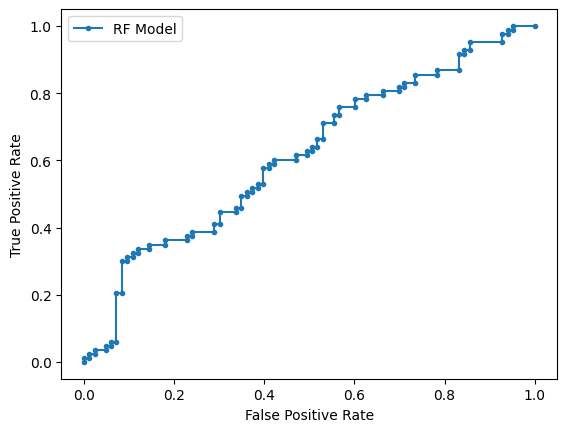

AUC-ROC  0.6160545797648425


In [ ]:
# calculate roc curves
best_model_fpr, best_model_tpr, _ = roc_curve(y_test, y_prob)
plt.plot(best_model_fpr, best_model_tpr, marker='.', label='RF Model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

AUC = roc_auc_score(y_test, y_prob)
print('AUC-ROC ',AUC)
